# ROC Curves, Sensitivity, and Specificity

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain how a continuous score and a threshold produce a **binary classifier**.
2. Construct and interpret a **confusion matrix** (TP, FP, TN, FN).
3. Define **sensitivity** (true positive rate) and **specificity** (true negative rate) and compute them from data.
4. Build an **ROC curve** from scratch by sweeping a threshold.
5. Compute and interpret the **AUC** (area under the ROC curve).
6. Use `sklearn.metrics` for ROC analysis and compare with your from-scratch implementation.

## Prerequisites

- [Module 02 — Continuous distributions](../02_distributions/02_continuous_distributions.ipynb) — Normal PDF/CDF
- [Notebook 01 — Hypothesis framework](01_hypothesis_framework.ipynb) — Type I / Type II errors, significance level

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0 scikit-learn"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

In [2]:
from manim import *

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.manim_utils import C, COLORS, PALETTE

cfg.apply_manim_config()

---

## 1. Binary Classification from Continuous Scores

Many real-world decision problems reduce to a binary choice — disease vs. healthy, spam vs. legitimate, signal vs. background — but the raw measurement is a **continuous score**.

**Example — medical screening.** A blood test returns a biomarker concentration $x \in [0, \infty)$. The physician must decide: *does this patient have the disease?* The decision rule is simple:

$$\text{Classify as positive (disease)} \iff x \geq t$$

where $t$ is a **threshold** (also called a **cut-off** or **decision boundary**).

The threshold controls the tradeoff:
- **Low threshold** $\Rightarrow$ almost everyone is classified positive $\Rightarrow$ catch nearly all disease cases, but many false alarms.
- **High threshold** $\Rightarrow$ very few positives $\Rightarrow$ few false alarms, but miss many disease cases.

There is no free lunch: lowering one type of error raises the other. The ROC curve is the tool that makes this tradeoff explicit.

Let us generate a concrete dataset. Suppose we have two populations — **healthy** individuals and **diseased** individuals — and the biomarker score follows a Normal distribution in each group, but with different means:

$$X_{\text{healthy}} \sim \mathcal{N}(\mu_0, \sigma^2), \qquad X_{\text{disease}} \sim \mathcal{N}(\mu_1, \sigma^2), \qquad \mu_1 > \mu_0.$$

In [ ]:
# Generate biomarker scores for healthy and diseased populations
n_healthy, n_disease = 500, 500
mu_healthy, mu_disease = 3.0, 5.5
sigma = 1.5

scores_healthy = rng.normal(mu_healthy, sigma, n_healthy)
scores_disease = rng.normal(mu_disease, sigma, n_disease)

# Combine into a single dataset
scores = np.concatenate([scores_healthy, scores_disease])
labels = np.concatenate(
    [np.zeros(n_healthy), np.ones(n_disease)]
)  # 0=healthy, 1=disease

print(
    f"Healthy:  n={n_healthy}, mean={scores_healthy.mean():.2f}, std={scores_healthy.std():.2f}"
)
print(
    f"Disease:  n={n_disease}, mean={scores_disease.mean():.2f}, std={scores_disease.std():.2f}"
)

Healthy:  n=500, mean=2.98, std=1.44
Disease:  n=500, mean=5.43, std=1.53


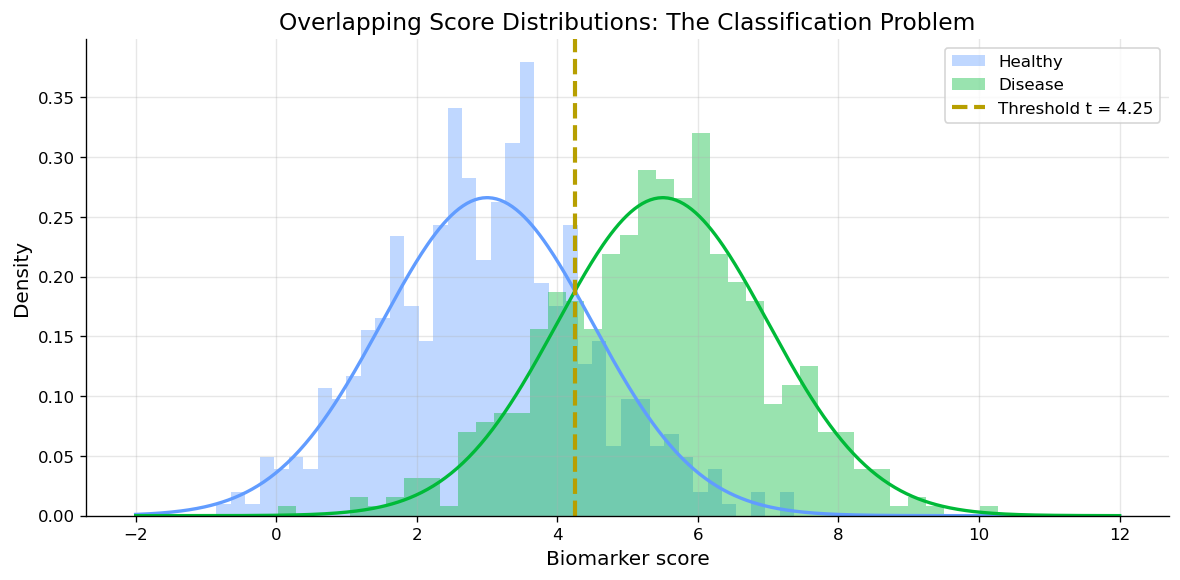

In [ ]:
# Visualise the two overlapping distributions
fig, ax = plt.subplots(figsize=(10, 5))
x_grid = np.linspace(-2, 12, 500)

ax.hist(
    scores_healthy, bins=40, density=True, alpha=0.4, color="#619CFF", label="Healthy"
)
ax.hist(
    scores_disease, bins=40, density=True, alpha=0.4, color="#00BA38", label="Disease"
)
ax.plot(x_grid, stats.norm.pdf(x_grid, mu_healthy, sigma), color="#619CFF", linewidth=2)
ax.plot(x_grid, stats.norm.pdf(x_grid, mu_disease, sigma), color="#00BA38", linewidth=2)

# Show a threshold
threshold_example = 4.25
ax.axvline(
    threshold_example,
    color="#B79F00",
    linewidth=2.5,
    linestyle="--",
    label=f"Threshold t = {threshold_example}",
)
ax.set_xlabel("Biomarker score")
ax.set_ylabel("Density")
ax.set_title("Overlapping Score Distributions: The Classification Problem")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The overlap region is where misclassification is unavoidable: some healthy individuals have high scores (false positives) and some diseased individuals have low scores (false negatives). The threshold determines exactly where we draw the line.

---

## 2. The Confusion Matrix

For a given threshold $t$, every individual in the dataset falls into one of four categories:

|                                 | **Predicted Positive** ($x \geq t$) | **Predicted Negative** ($x < t$) |
|---------------------------------|-------------------------------------|----------------------------------|
| **Actually Positive** (disease) | True Positive (TP)                  | False Negative (FN)              |
| **Actually Negative** (healthy) | False Positive (FP)                 | True Negative (TN)               |

This $2 \times 2$ table is called the **confusion matrix**. Every classification metric — sensitivity, specificity, precision, accuracy, F1 score — is a function of these four counts.

### Medical screening example

Consider a mammogram screening program for breast cancer:

- **TP:** The mammogram flags a suspicious mass, and the patient does have cancer. Correct detection.
- **FP:** The mammogram flags a suspicious mass, but the patient is healthy. Unnecessary biopsy, anxiety.
- **FN:** The mammogram appears clear, but the patient actually has cancer. **Missed diagnosis** — the most dangerous error.
- **TN:** The mammogram appears clear, and the patient is healthy. Correct all-clear.

The costs of FP and FN are very different: a false negative (missed cancer) is far worse than a false positive (unnecessary follow-up). This asymmetry is why we need to think carefully about the threshold.

In [5]:
def confusion_matrix_counts(y_true, y_scores, threshold):
    """Compute TP, FP, TN, FN for a given threshold."""
    y_pred = (y_scores >= threshold).astype(int)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return tp, fp, tn, fn


# Compute confusion matrix at our example threshold
tp, fp, tn, fn = confusion_matrix_counts(labels, scores, threshold_example)

print(f"Threshold t = {threshold_example}")
print(f"{'':>20s} Pred +    Pred -")
print(f"{'Actually + (disease)':>20s}   {tp:>4d}      {fn:>4d}   (TP, FN)")
print(f"{'Actually - (healthy)':>20s}   {fp:>4d}      {tn:>4d}   (FP, TN)")
print(f"\nTotal positives (disease): {tp + fn}")
print(f"Total negatives (healthy): {fp + tn}")

Threshold t = 4.25
                     Pred +    Pred -
Actually + (disease)    387       113   (TP, FN)
Actually - (healthy)     92       408   (FP, TN)

Total positives (disease): 500
Total negatives (healthy): 500


---

## 3. Sensitivity and Specificity

The two most important metrics for diagnostic tests are **sensitivity** and **specificity**. They answer two different conditional-probability questions:

### Sensitivity (True Positive Rate, TPR)

> **Sensitivity** $= P(\text{test positive} \mid \text{disease}) = \frac{\text{TP}}{\text{TP} + \text{FN}}$

"Among all people who actually have the disease, what fraction does the test correctly detect?"

A test with high sensitivity **rarely misses** a true case. In screening, this is critical: you don't want to send someone home with undetected cancer.

### Specificity (True Negative Rate, TNR)

> **Specificity** $= P(\text{test negative} \mid \text{healthy}) = \frac{\text{TN}}{\text{TN} + \text{FP}}$

"Among all people who are actually healthy, what fraction does the test correctly clear?"

A test with high specificity **rarely raises false alarms**. In confirmatory testing, this matters: you don't want to subject healthy people to invasive follow-up procedures.

### The complementary rate: False Positive Rate

The **false positive rate** (FPR) is the complement of specificity:

$$\text{FPR} = 1 - \text{Specificity} = \frac{\text{FP}}{\text{FP} + \text{TN}}$$

The ROC curve plots TPR vs. FPR, so it directly visualises the sensitivity–specificity tradeoff.

### Concrete example

Let us compute these for several thresholds:

In [ ]:
print(
    f"{'Threshold':>10s}  {'TPR (Sens)':>10s}  {'TNR (Spec)':>10s}  {'FPR':>8s}  {'TP':>5s}  {'FP':>5s}  {'FN':>5s}  {'TN':>5s}"
)
print("-" * 78)

for t in [1.0, 2.0, 3.0, 4.0, 4.25, 5.0, 6.0, 7.0, 8.0]:
    tp, fp, tn, fn = confusion_matrix_counts(labels, scores, t)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(
        f"{t:>10.2f}  {tpr:>10.3f}  {tnr:>10.3f}  {fpr:>8.3f}  {tp:>5d}  {fp:>5d}  {fn:>5d}  {tn:>5d}"
    )

 Threshold  TPR (Sens)  TNR (Spec)       FPR     TP     FP     FN     TN
------------------------------------------------------------------------------
      1.00       0.998       0.086     0.914    499    457      1     43
      2.00       0.982       0.250     0.750    491    375      9    125
      3.00       0.938       0.498     0.502    469    251     31    249
      4.00       0.816       0.776     0.224    408    112     92    388
      4.25       0.774       0.816     0.184    387     92    113    408
      5.00       0.634       0.916     0.084    317     42    183    458
      6.00       0.360       0.980     0.020    180     10    320    490
      7.00       0.144       0.996     0.004     72      2    428    498
      8.00       0.046       1.000     0.000     23      0    477    500


Observe the tradeoff: as the threshold increases, sensitivity (TPR) decreases while specificity (TNR) increases. At a very low threshold ($t = 1$), we catch virtually all disease cases but also flag many healthy people. At a very high threshold ($t = 8$), we have almost no false positives but miss most disease cases.

**There is no single "best" threshold.** The optimal choice depends on the relative costs of false positives vs. false negatives, which is a domain decision, not a purely statistical one.

---

## 4. The ROC Curve

The **Receiver Operating Characteristic (ROC) curve** visualises the full tradeoff between sensitivity and specificity across *all possible thresholds*.

### Construction

1. Start with the most extreme threshold (so extreme that everything is classified negative): the point $(\text{FPR}, \text{TPR}) = (0, 0)$.
2. Gradually lower the threshold. As you do, more samples are classified positive:
   - Each new true positive moves the curve **up** (TPR increases).
   - Each new false positive moves the curve **right** (FPR increases).
3. End at the opposite extreme (everything classified positive): the point $(1, 1)$.

### What each point on the curve represents

Every point on the ROC curve corresponds to a specific threshold and tells you: "If I use this threshold, my true positive rate is $y$ and my false positive rate is $x$." Moving along the curve means changing the threshold.

### Reference lines

- **The diagonal** ($\text{TPR} = \text{FPR}$): This is the ROC curve of a **random classifier** that ignores the data entirely. No matter what threshold you pick, the rate of catching true positives equals the rate of false positives — no discriminatory power.
- **The upper-left corner** $(0, 1)$: This is **perfect classification** — 100% sensitivity and 100% specificity. No real test achieves this (unless the distributions don't overlap at all).
- **A curve below the diagonal** means the classifier is worse than random — just flip its predictions.

A good classifier has an ROC curve that hugs the upper-left corner.

---

## 5. From-Scratch ROC Curve

Let us implement the ROC curve computation from scratch. The algorithm is straightforward: sweep across all unique score values as thresholds, and at each one compute the TPR and FPR.

In [7]:
def roc_curve_scratch(y_true, y_scores):
    """Compute the ROC curve from scratch.

    Parameters
    ----------
    y_true : array of 0/1 labels
    y_scores : array of continuous scores (higher = more likely positive)

    Returns
    -------
    fpr_list, tpr_list, thresholds : arrays
    """
    # Sort thresholds from high to low (so we go from (0,0) toward (1,1))
    thresholds = np.sort(np.unique(y_scores))[::-1]

    total_pos = np.sum(y_true == 1)
    total_neg = np.sum(y_true == 0)

    fpr_list = [0.0]  # Start at origin
    tpr_list = [0.0]
    thresh_list = [thresholds[0] + 1]  # Threshold higher than any score

    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        tpr = tp / total_pos
        fpr = fp / total_neg
        tpr_list.append(tpr)
        fpr_list.append(fpr)
        thresh_list.append(t)

    return np.array(fpr_list), np.array(tpr_list), np.array(thresh_list)


fpr_scratch, tpr_scratch, thresholds_scratch = roc_curve_scratch(labels, scores)
print(f"Number of threshold points: {len(thresholds_scratch)}")

Number of threshold points: 1001


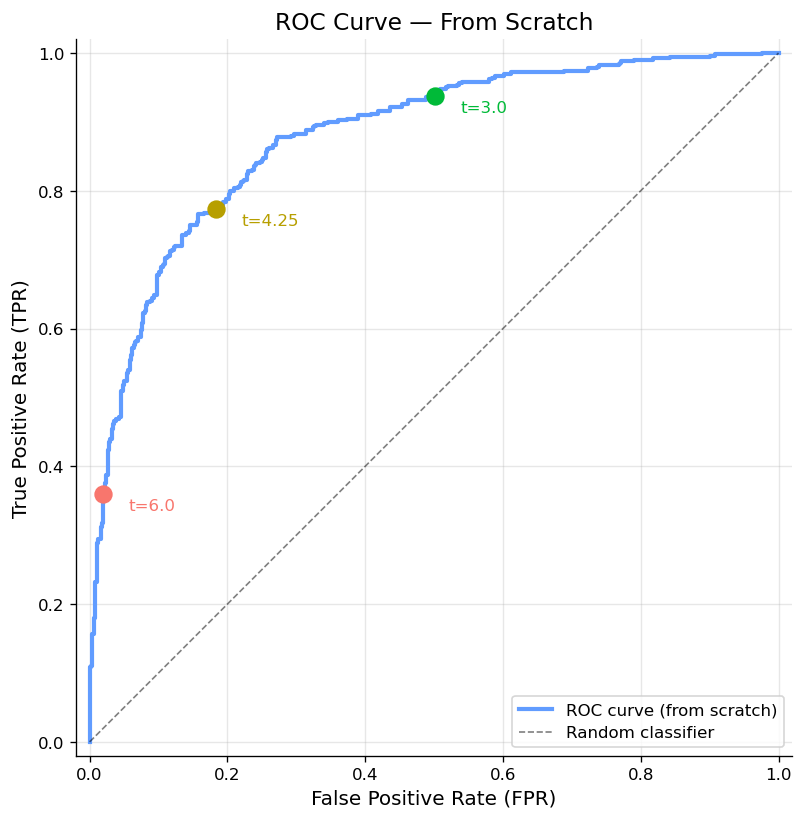

In [ ]:
# Plot the from-scratch ROC curve
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(
    fpr_scratch,
    tpr_scratch,
    color="#619CFF",
    linewidth=2.5,
    label="ROC curve (from scratch)",
)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random classifier")

# Mark a few specific thresholds
for t_mark, marker_color in [(3.0, "#00BA38"), (4.25, "#B79F00"), (6.0, "#F8766D")]:
    idx = np.argmin(np.abs(thresholds_scratch - t_mark))
    ax.plot(
        fpr_scratch[idx],
        tpr_scratch[idx],
        "o",
        color=marker_color,
        markersize=10,
        zorder=5,
    )
    ax.annotate(
        f"t={t_mark}",
        xy=(fpr_scratch[idx], tpr_scratch[idx]),
        xytext=(15, -10),
        textcoords="offset points",
        fontsize=10,
        color=marker_color,
    )

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("ROC Curve — From Scratch")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

Each colored dot corresponds to a specific threshold choice. At $t = 3.0$ (green) we have high sensitivity but also high FPR. At $t = 6.0$ (red) we have low FPR but also lower sensitivity. The gold dot at $t = 4.25$ sits in a balanced region.

The curve bows toward the upper-left corner, showing that this classifier has genuine discriminatory power — much better than the random diagonal.

---

## 6. AUC — Area Under the ROC Curve

The **AUC** (Area Under the Curve) summarises the entire ROC curve into a single number.

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d(\text{FPR})$$

### Interpretation

| AUC     | Meaning                                                            |
|---------|--------------------------------------------------------------------|
| $1.0$   | **Perfect** separation — there exists a threshold with zero errors |
| $0.5$   | **Random** — the classifier has no discriminatory power            |
| $< 0.5$ | **Worse than random** (flip the predictions)                       |

### Probabilistic interpretation

The AUC has an elegant probabilistic meaning:

> **AUC** $= P(S_{\text{positive}} > S_{\text{negative}})$

where $S_{\text{positive}}$ is the score of a randomly chosen positive example and $S_{\text{negative}}$ is the score of a randomly chosen negative example.

In other words: if you pick one diseased person and one healthy person at random, the AUC is the probability that the diseased person has a higher biomarker score. This is the **concordance probability** — the classifier ranks a random positive above a random negative with this probability.

### Computing AUC from scratch

We can compute the AUC using the **trapezoidal rule** (numerical integration of the ROC curve):

In [9]:
def auc_trapz(fpr, tpr):
    """Compute AUC using the trapezoidal rule."""
    # Sort by FPR to ensure correct integration order
    order = np.argsort(fpr)
    fpr_sorted = fpr[order]
    tpr_sorted = tpr[order]
    return np.trapz(tpr_sorted, fpr_sorted)


auc_scratch = auc_trapz(fpr_scratch, tpr_scratch)
print(f"AUC (from scratch, trapezoidal rule): {auc_scratch:.4f}")

AUC (from scratch, trapezoidal rule): 0.8788


In [ ]:
# Verify the probabilistic interpretation: concordance probability
n_pairs = 100_000
idx_pos = rng.choice(np.where(labels == 1)[0], size=n_pairs)
idx_neg = rng.choice(np.where(labels == 0)[0], size=n_pairs)

concordance = np.mean(scores[idx_pos] > scores[idx_neg])
print(f"AUC (from scratch):            {auc_scratch:.4f}")
print(f"Concordance probability (MC):  {concordance:.4f}")
print(
    f"\nThese should be approximately equal — the AUC IS the concordance probability."
)

AUC (from scratch):            0.8788
Concordance probability (MC):  0.8788

These should be approximately equal — the AUC IS the concordance probability.


---

## 7. Manim Animation: ROC Curve Construction

The following animation shows the ROC curve being traced as a threshold sweeps across the score distributions. The **top panel** shows two overlapping bell curves (positive class in green, negative class in blue) with a moving vertical threshold line. The **bottom panel** traces the corresponding point on the ROC curve.

Manim Community v0.18.1

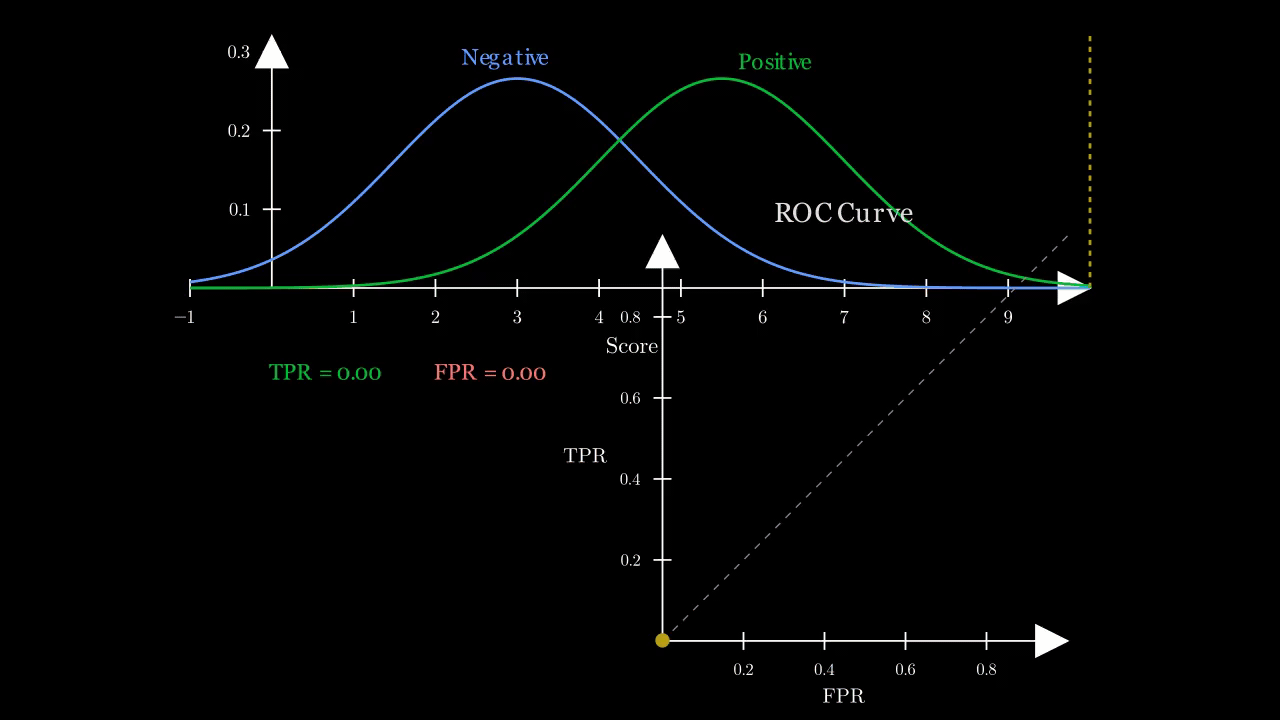

In [ ]:
%%manim -qm -v WARNING ROCCurveTrace


class ROCCurveTrace(Scene):
    def construct(self):
        # --- Parameters ---
        mu_neg, mu_pos, sigma = 3.0, 5.5, 1.5
        x_lo, x_hi = -1, 10

        # --- Top axes: score distributions ---
        ax_top = Axes(
            x_range=[x_lo, x_hi, 1],
            y_range=[0, 0.32, 0.1],
            x_length=10,
            y_length=2.8,
            axis_config={"include_numbers": True, "font_size": 20},
        ).to_edge(UP, buff=0.4)
        top_xlabel = MathTex("\\text{Score}", font_size=24).next_to(
            ax_top, DOWN, buff=0.15
        )

        # PDF functions
        from scipy.stats import norm as scipy_norm

        neg_pdf = lambda x: scipy_norm.pdf(x, mu_neg, sigma)
        pos_pdf = lambda x: scipy_norm.pdf(x, mu_pos, sigma)

        curve_neg = ax_top.plot(
            neg_pdf, x_range=[x_lo, x_hi, 0.05], color=C.PERIWINKLE, stroke_width=3
        )
        curve_pos = ax_top.plot(
            pos_pdf, x_range=[x_lo, x_hi, 0.05], color=C.EMERALD, stroke_width=3
        )

        label_neg = (
            Text("Negative", font_size=18, color=C.PERIWINKLE)
            .next_to(curve_neg, UP, buff=0.1)
            .shift(LEFT * 1.5)
        )
        label_pos = (
            Text("Positive", font_size=18, color=C.EMERALD)
            .next_to(curve_pos, UP, buff=0.1)
            .shift(RIGHT * 1.5)
        )

        # --- Bottom axes: ROC curve ---
        ax_bot = (
            Axes(
                x_range=[0, 1, 0.2],
                y_range=[0, 1, 0.2],
                x_length=4.5,
                y_length=4.5,
                axis_config={"include_numbers": True, "font_size": 18},
            )
            .to_edge(DOWN, buff=0.5)
            .shift(RIGHT * 2.5)
        )
        roc_xlabel = MathTex("\\text{FPR}", font_size=22).next_to(
            ax_bot, DOWN, buff=0.15
        )
        roc_ylabel = MathTex("\\text{TPR}", font_size=22).next_to(
            ax_bot, LEFT, buff=0.15
        )
        roc_title = Text("ROC Curve", font_size=22, color=C.LABEL).next_to(
            ax_bot, UP, buff=0.15
        )

        # Diagonal reference
        diag = DashedLine(
            ax_bot.c2p(0, 0),
            ax_bot.c2p(1, 1),
            color=GREY,
            stroke_width=1.5,
            dash_length=0.08,
        )

        # --- Threshold tracker ---
        t_tracker = ValueTracker(x_hi)  # start from right

        # Vertical threshold line
        threshold_line = always_redraw(
            lambda: DashedLine(
                ax_top.c2p(t_tracker.get_value(), 0),
                ax_top.c2p(t_tracker.get_value(), 0.32),
                color=C.GOLD,
                stroke_width=3,
                dash_length=0.06,
            )
        )

        # Shaded TP area (right of threshold under positive curve)
        tp_area = always_redraw(
            lambda: ax_top.get_area(
                curve_pos,
                x_range=[t_tracker.get_value(), x_hi],
                color=C.EMERALD,
                opacity=0.35,
            )
        )

        # Shaded FP area (right of threshold under negative curve)
        fp_area = always_redraw(
            lambda: ax_top.get_area(
                curve_neg,
                x_range=[t_tracker.get_value(), x_hi],
                color=C.SALMON,
                opacity=0.35,
            )
        )

        # TPR / FPR labels below the top axes
        def make_rate_label():
            t = t_tracker.get_value()
            tpr_val = 1 - scipy_norm.cdf(t, mu_pos, sigma)
            fpr_val = 1 - scipy_norm.cdf(t, mu_neg, sigma)
            return (
                VGroup(
                    Text(f"TPR = {tpr_val:.2f}", font_size=18, color=C.EMERALD),
                    Text(f"FPR = {fpr_val:.2f}", font_size=18, color=C.SALMON),
                )
                .arrange(RIGHT, buff=0.6)
                .next_to(ax_top, DOWN, buff=0.45)
                .shift(LEFT * 2.5)
            )

        rate_label = always_redraw(make_rate_label)

        # --- ROC point that traces the curve ---
        roc_dot = always_redraw(
            lambda: Dot(
                ax_bot.c2p(
                    1 - scipy_norm.cdf(t_tracker.get_value(), mu_neg, sigma),
                    1 - scipy_norm.cdf(t_tracker.get_value(), mu_pos, sigma),
                ),
                color=C.GOLD,
                radius=0.08,
            )
        )

        # Pre-computed ROC curve path (draw the full curve faintly, trace over it)
        t_values = np.linspace(x_hi, x_lo, 300)
        roc_points = [
            ax_bot.c2p(
                1 - scipy_norm.cdf(tv, mu_neg, sigma),
                1 - scipy_norm.cdf(tv, mu_pos, sigma),
            )
            for tv in t_values
        ]
        full_roc = VMobject(color=C.CYAN, stroke_width=2.5)
        full_roc.set_points_smoothly([np.array(p) for p in roc_points])

        # Traced path
        traced_path = TracedPath(
            lambda: ax_bot.c2p(
                1 - scipy_norm.cdf(t_tracker.get_value(), mu_neg, sigma),
                1 - scipy_norm.cdf(t_tracker.get_value(), mu_pos, sigma),
            ),
            stroke_color=C.CYAN,
            stroke_width=3,
        )

        # --- Build scene ---
        self.add(ax_top, top_xlabel, curve_neg, curve_pos, label_neg, label_pos)
        self.add(ax_bot, roc_xlabel, roc_ylabel, roc_title, diag)
        self.add(threshold_line, tp_area, fp_area, rate_label)
        self.add(roc_dot, traced_path)

        self.wait(0.5)

        # Sweep threshold from right to left
        self.play(
            t_tracker.animate.set_value(x_lo),
            run_time=10,
            rate_func=linear,
        )
        self.wait(1)

In the animation, watch how:

- When the threshold is far to the right, both TP (green shading) and FP (salmon shading) areas are tiny — the ROC point is near $(0, 0)$.
- As the threshold moves left through the overlap region, the TP area grows faster than the FP area — the ROC curve bows above the diagonal.
- When the threshold passes far to the left, both areas saturate at 1.0 — the ROC point approaches $(1, 1)$.

The further the two bell curves are separated, the more the ROC curve bows toward the upper-left corner.

---

## 8. Using `sklearn.metrics`

In practice you would use scikit-learn's optimised implementation rather than the from-scratch version. Let us compare the two:

In [12]:
from sklearn.metrics import roc_curve as sk_roc_curve, roc_auc_score

fpr_sk, tpr_sk, thresholds_sk = sk_roc_curve(labels, scores)
auc_sk = roc_auc_score(labels, scores)

print(f"AUC (from scratch):  {auc_scratch:.6f}")
print(f"AUC (sklearn):       {auc_sk:.6f}")
print(f"Difference:          {abs(auc_scratch - auc_sk):.2e}")

AUC (from scratch):  0.878834
AUC (sklearn):       0.878856
Difference:          2.20e-05


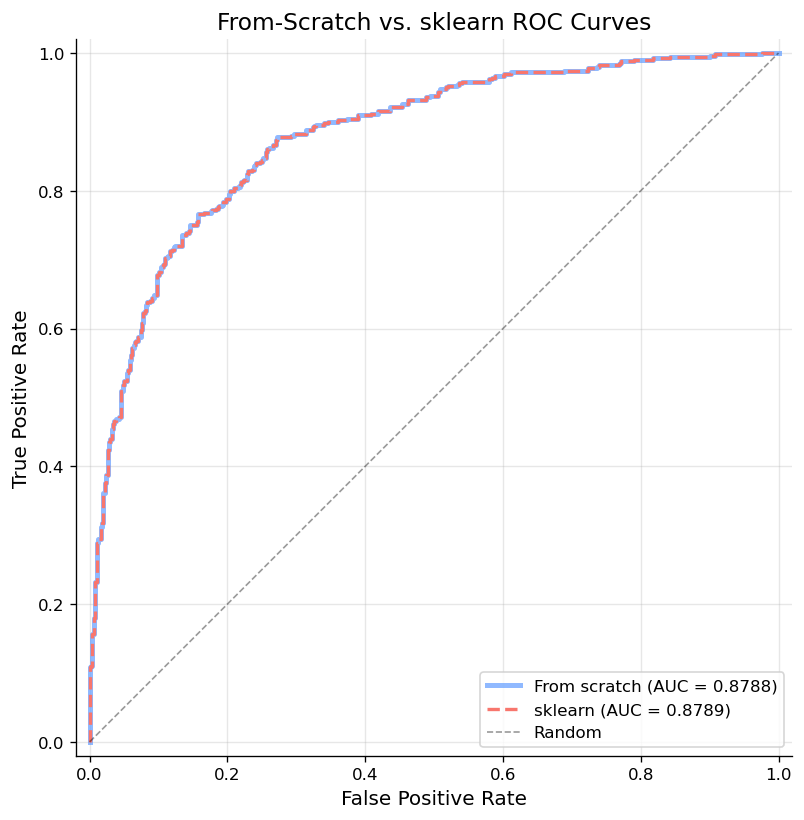

In [ ]:
# Overlay both ROC curves to confirm they match
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(
    fpr_scratch,
    tpr_scratch,
    color="#619CFF",
    linewidth=3,
    alpha=0.7,
    label=f"From scratch (AUC = {auc_scratch:.4f})",
)
ax.plot(
    fpr_sk,
    tpr_sk,
    color="#F8766D",
    linewidth=2,
    linestyle="--",
    label=f"sklearn (AUC = {auc_sk:.4f})",
)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Random")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("From-Scratch vs. sklearn ROC Curves")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

The two curves are visually indistinguishable — our from-scratch implementation agrees with sklearn. In practice, `sklearn.metrics.roc_curve` uses a more efficient algorithm (sorting the scores once, then scanning), but the mathematical result is the same.

---

## 9. Multi-Separation Example: How Separation Affects the ROC

How does the degree of separation between the positive and negative distributions affect the ROC curve? Intuitively, the more separated the distributions are, the easier the classification problem and the better the ROC curve.

Let us compare ROC curves for signal and background distributions separated by $1\sigma$, $2\sigma$, and $3\sigma$ . We fix $\sigma = 1$ and shift the means apart:

$$\text{Background} \sim \mathcal{N}(0, 1), \qquad \text{Signal} \sim \mathcal{N}(d, 1), \qquad d \in \{1, 2, 3\}$$

Here $d$ is the separation in units of $\sigma$.

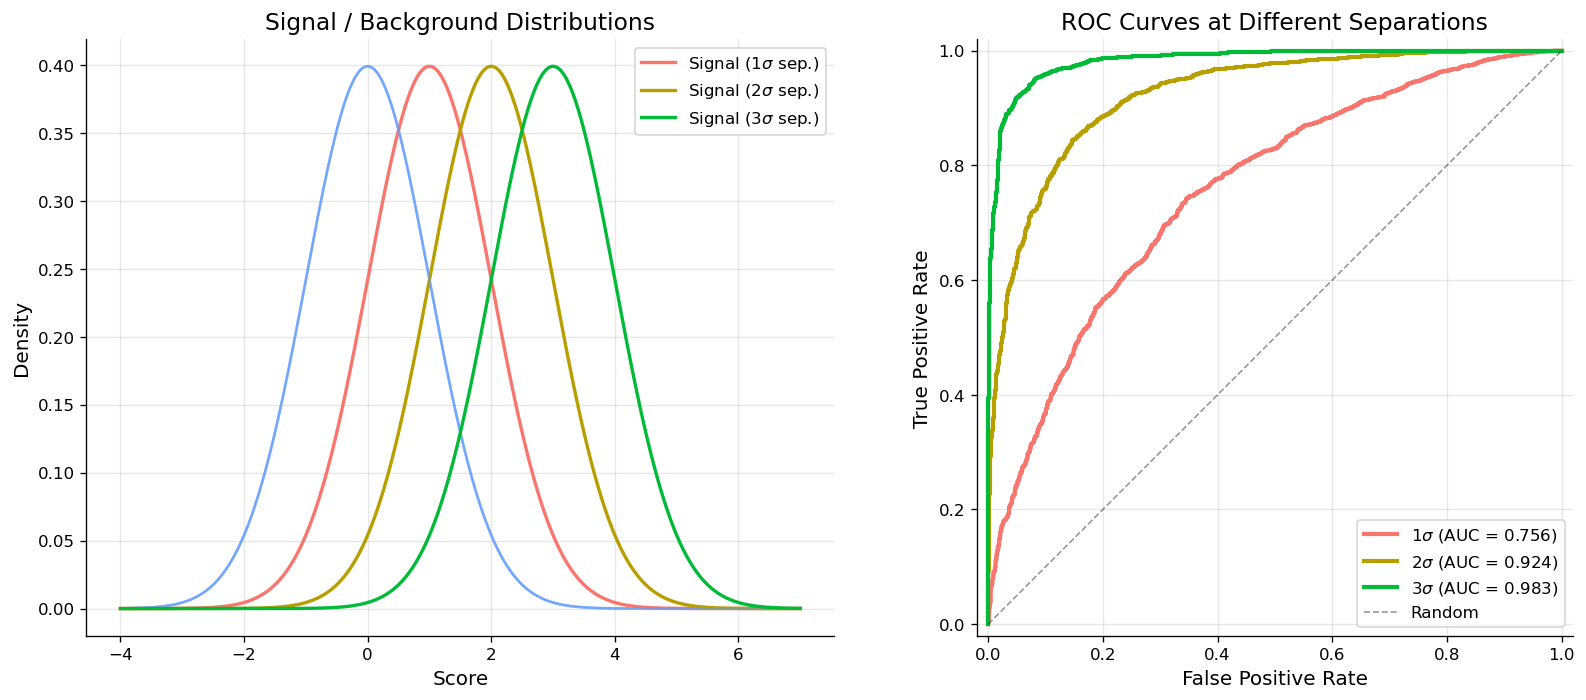

In [ ]:
n_per_class = 2000
separations = [1, 2, 3]  # in units of sigma
sep_colors = ["#F8766D", "#B79F00", "#00BA38"]  # salmon, gold, emerald

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for d, color in zip(separations, sep_colors):
    # Generate data
    bg = rng.normal(0, 1, n_per_class)
    sig = rng.normal(d, 1, n_per_class)
    all_scores = np.concatenate([bg, sig])
    all_labels = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

    # Score distributions
    x_grid = np.linspace(-4, 7, 500)
    axes[0].plot(
        x_grid, stats.norm.pdf(x_grid, 0, 1), color="#619CFF", linewidth=1.5, alpha=0.5
    )
    axes[0].plot(
        x_grid,
        stats.norm.pdf(x_grid, d, 1),
        color=color,
        linewidth=2,
        label=f"Signal ({d}$\\sigma$ sep.)",
    )

    # ROC curve (using sklearn for efficiency)
    fpr_d, tpr_d, _ = sk_roc_curve(all_labels, all_scores)
    auc_d = roc_auc_score(all_labels, all_scores)
    axes[1].plot(
        fpr_d,
        tpr_d,
        color=color,
        linewidth=2.5,
        label=f"{d}$\\sigma$ (AUC = {auc_d:.3f})",
    )

# Left panel formatting
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Density")
axes[0].set_title("Signal / Background Distributions")
axes[0].legend(fontsize=10)

# Right panel formatting
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves at Different Separations")
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_aspect("equal")
axes[1].legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

Key observations:

- At **$1\sigma$ separation**, the distributions overlap heavily. The ROC curve is close to the diagonal — classification is hard. The AUC is modest.
- At **$2\sigma$ separation**, the ROC curve clearly bows toward the upper left. This is roughly the situation in our medical screening example above ($\Delta\mu / \sigma = 2.5/1.5 \approx 1.67$).
- At **$3\sigma$ separation**, the distributions barely overlap. The ROC curve hugs the upper-left corner and the AUC approaches 1.0.

In particle physics, the signal-background separation problem is ubiquitous: you are looking for rare signal events buried in a large background. The ROC curve (or equivalently, the signal efficiency vs. background rejection curve) is the standard tool for evaluating classifiers in that context.

### Analytical ROC for Gaussian signal and background

When both classes are Gaussian with equal variance, the ROC curve has a closed-form expression. If $X_- \sim \mathcal{N}(0, 1)$ and $X_+ \sim \mathcal{N}(d, 1)$:

$$\text{TPR} = \Phi\big(\Phi^{-1}(\text{FPR}) + d\big)$$

where $\Phi$ is the standard Normal CDF. This is a consequence of both TPR and FPR being complementary CDFs evaluated at the same threshold.

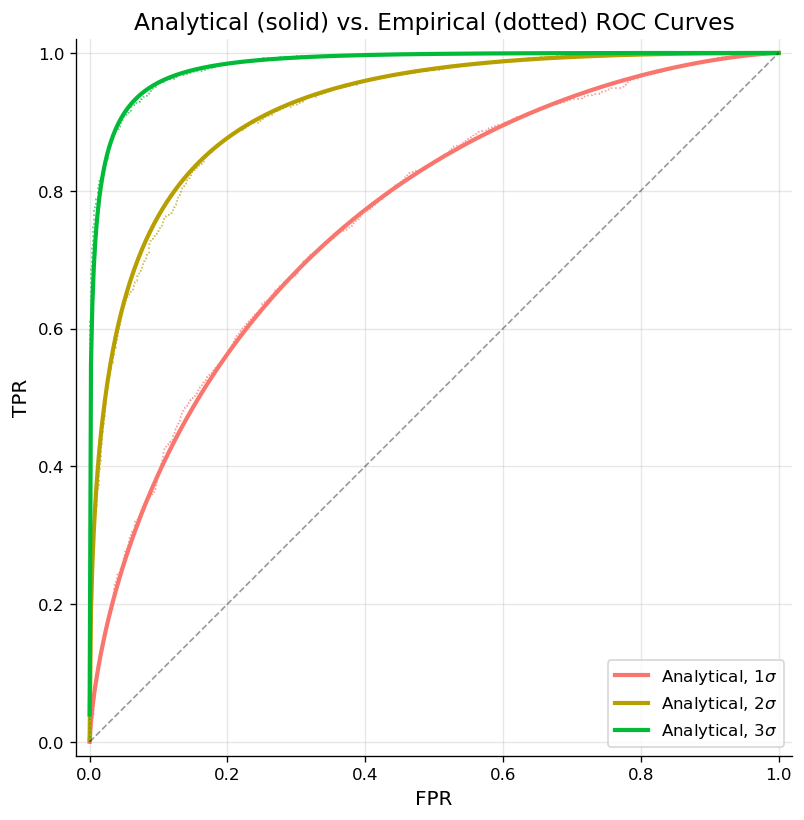

In [ ]:
# Verify the analytical formula
fig, ax = plt.subplots(figsize=(7, 7))
fpr_grid = np.linspace(1e-6, 1 - 1e-6, 500)

for d, color in zip(separations, sep_colors):
    # Analytical ROC
    tpr_analytical = stats.norm.cdf(stats.norm.ppf(fpr_grid) + d)
    ax.plot(
        fpr_grid,
        tpr_analytical,
        color=color,
        linewidth=2.5,
        label=f"Analytical, {d}$\\sigma$",
    )

    # Empirical ROC (from data generated above)
    bg = rng.normal(0, 1, n_per_class)
    sig = rng.normal(d, 1, n_per_class)
    all_scores = np.concatenate([bg, sig])
    all_labels = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])
    fpr_emp, tpr_emp, _ = sk_roc_curve(all_labels, all_scores)
    ax.plot(fpr_emp, tpr_emp, color=color, linewidth=1, linestyle=":", alpha=0.7)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Analytical (solid) vs. Empirical (dotted) ROC Curves")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

---

## Exercises

**Exercise 5.1 (Confusion matrix by hand).** A COVID rapid test is applied to 200 people, of whom 40 are infected. The test correctly identifies 35 of the 40 infected (TP = 35) and correctly clears 140 of the 160 healthy (TN = 140). Compute: (a) the confusion matrix; (b) sensitivity; (c) specificity; (d) the false positive rate; (e) the positive predictive value $\text{PPV} = \text{TP} / (\text{TP} + \text{FP})$. Discuss why PPV depends on prevalence while sensitivity does not.

**Exercise 5.2 (ROC from scratch — edge cases).** Modify `roc_curve_scratch` to handle the edge case where some scores are tied (i.e., multiple samples have exactly the same score). Test it on a small dataset with ties and verify it matches `sklearn.metrics.roc_curve`.

**Exercise 5.3 (AUC by the Mann–Whitney U statistic).** The AUC equals $U / (n_+ \cdot n_-)$ where $U$ is the Mann–Whitney U statistic. Implement this: for every (positive, negative) pair, count how many times the positive has a higher score. Divide by the total number of pairs. Verify this matches your trapezoidal AUC and `roc_auc_score`.

**Exercise 5.4 (Effect of class imbalance on the ROC).** Generate a dataset with 50 positives and 950 negatives (both $\mathcal{N}(d, 1)$ with $d = 2$). Compute and plot the ROC curve. Does the AUC change compared to the balanced case (500/500)? Why or why not? Now plot the **precision-recall curve** for both settings and compare. Which metric is more affected by class imbalance?

**Exercise 5.5 (Optimal threshold).** For the medical screening dataset in this notebook (Section 1), find the threshold that maximises **Youden's J statistic**: $J = \text{TPR} - \text{FPR}$. This is the point on the ROC curve farthest from the diagonal. What are the sensitivity and specificity at this threshold? Plot the ROC curve and mark the optimal point.

---

## Key Takeaways

This notebook completes **Module 05 — Hypothesis Testing**. Here are the key ideas from this final notebook:

1. A binary classifier is defined by a continuous score and a **threshold**. The threshold controls the tradeoff between catching true positives and avoiding false positives.
2. The **confusion matrix** (TP, FP, TN, FN) is the foundation. Every classification metric is derived from it.
3. **Sensitivity** (TPR) $= P(\text{test}+|\text{disease})$ measures how well we detect true cases. **Specificity** (TNR) $= P(\text{test}-|\text{healthy})$ measures how well we avoid false alarms.
4. The **ROC curve** plots TPR vs. FPR across all thresholds, making the full tradeoff visible. The diagonal is the random baseline.
5. **AUC** summarises the ROC into a single number: 1.0 = perfect, 0.5 = random. It equals the probability that a random positive scores higher than a random negative.
6. Greater separation between the class distributions yields ROC curves closer to the upper-left corner and AUC closer to 1.0.
7. **There is no universally optimal threshold** — the choice depends on the relative costs of FP and FN in your application.

**Next module:** [Module 06 — Linear Models: Simple Linear Regression](../06_linear_models/01_simple_linear_regression.ipynb)

In [16]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/AlphaBetaTradeoff@2026-03-19@17-42-26.gif
  ✓ media/gifs/ROCCurveTrace@2026-03-19@17-49-47.gif
  ✓ media/gifs/ROCCurveTrace_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
